<a href="https://colab.research.google.com/github/mbassi237/mbassi237/blob/master/I3AFD_Projet4_BioMistral_Update_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Structuration et synthèse agentique de comptes rendus de radiologie

## Architecture des modèles
- **BioMistral-7B** (quantifié 4-bit) Agents médicaux : Extracteur, Structureur, Vérificateur
- **Mistral-7B-Instruct** (quantifié 4-bit) Agent vulgarisation patient
- **Groq API** (llama-3.3-70b) Agent résumé médecin

## Cellule 1 — Installation des dépendances

In [1]:
!pip install langgraph langchain transformers accelerate -q
!pip install bitsandbytes -q       # quantification 4-bit
!pip install groq rouge-score bert-score -q
!pip install sentencepiece -q      # nécessaire pour BioMistral tokenizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00


## Cellule 2 — Parsing XML

In [3]:
import os
import xml.etree.ElementTree as ET
from google.colab import drive

drive.mount('/content/drive')

def parser_rapport_xml(chemin_fichier):
    """
    Lit un fichier XML du dataset OpenI et extrait
    les champs FINDINGS et IMPRESSION.
    """
    resultat = {
        "fichier"    : os.path.basename(chemin_fichier),
        "id_rapport" : "",
        "indication" : "",
        "comparison" : "",
        "findings"   : "",
        "impression" : "",
        "erreur"     : "",
    }
    try:
        tree = ET.parse(chemin_fichier)
        root = tree.getroot()
        balise_uid = root.find(".//uId")
        if balise_uid is not None:
            resultat["id_rapport"] = balise_uid.get("id", "")
        for balise in root.iter("AbstractText"):
            label = balise.get("Label", "").upper().strip()
            texte = (balise.text or "").strip()
            if label == "FINDINGS":
                resultat["findings"] = texte
            elif label == "IMPRESSION":
                resultat["impression"] = texte
            elif label == "INDICATION":
                resultat["indication"] = texte
            elif label == "COMPARISON":
                resultat["comparison"] = texte
    except ET.ParseError as e:
        resultat["erreur"] = f"XML invalide : {str(e)}"
    except Exception as e:
        resultat["erreur"] = f"Erreur : {str(e)}"
    return resultat

# Adapter ce chemin selon votre Drive
dossier_rapports = "/content/drive/MyDrive/ecgen-radiology/"

fichiers_xml = []
for racine, _, fichiers in os.walk(dossier_rapports):
    for f in fichiers:
        if f.endswith(".xml"):
            fichiers_xml.append(os.path.join(racine, f))

print(f"{len(fichiers_xml)} fichiers XML trouvés")

Mounted at /content/drive
3955 fichiers XML trouvés


## Cellule 3 — Sauvegarde JSON

In [4]:
import json
from tqdm import tqdm

tous_rapports = []
for chemin in tqdm(fichiers_xml, desc="Parsing XML"):
    rapport = parser_rapport_xml(chemin)
    if rapport["findings"] and rapport["impression"] and not rapport["erreur"]:
        tous_rapports.append(rapport)

output_filename = "radiology_reports.json"
with open(output_filename, "w", encoding="utf-8") as f:
    json.dump(tous_rapports, f, ensure_ascii=False, indent=2)

print(f"{len(tous_rapports)} rapports sauvegardés dans {output_filename}")

Parsing XML: 100%|██████████| 3955/3955 [01:29<00:00, 44.00it/s] 

3419 rapports sauvegardés dans radiology_reports.json


## Chargement de BioMistral-7B (quantifié 4-bit)

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Vérification GPU
print("Vérification GPU...")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU détecté : {gpu_name}")
    print(f"VRAM totale : {vram_gb:.1f} GB")
else:
    print("Pas de GPU")
    raise RuntimeError("GPU requis pour BioMistral-7B")

#Configuration quantification 4-bit
# La quantification 4-bit réduit la VRAM de ~14 GB à ~4-5 GB
config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,     # Double quantification = encore moins de VRAM
    bnb_4bit_quant_type="nf4"           # NF4 = meilleure qualité en 4-bit
)

#Chargement BioMistral-7B
NOM_MODELE_BIO = "BioMistral/BioMistral-7B"

print(f"\n Chargement de {NOM_MODELE_BIO} en 4-bit...")
print("   (5-8 minutes pour le téléchargement)")

tokenizer_bio = AutoTokenizer.from_pretrained(
    NOM_MODELE_BIO,
    use_fast=True
)

modele_bio = AutoModelForCausalLM.from_pretrained(
    NOM_MODELE_BIO,
    quantization_config=config_4bit,
    device_map="auto",          # Répartit automatiquement sur GPU/CPU
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)
modele_bio.eval()  # Mode inférence uniquement

# Ajouter le pad token si absent
if tokenizer_bio.pad_token is None:
    tokenizer_bio.pad_token = tokenizer_bio.eos_token

# Vérification VRAM après chargement
vram_utilisee = torch.cuda.memory_allocated(0) / 1e9
print(f"\n BioMistral-7B chargé avec succès !")
print(f"   VRAM utilisée : {vram_utilisee:.1f} GB / {vram_gb:.1f} GB")

Vérification GPU...
GPU détecté : Tesla T4
VRAM totale : 15.6 GB

 Chargement de BioMistral/BioMistral-7B en 4-bit...
   (5-8 minutes pour le téléchargement)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/14.5G [00:00<?, ?B/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 47, in spawn_con

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


 BioMistral-7B chargé avec succès !
   VRAM utilisée : 4.1 GB / 15.6 GB


## Fonction d'inférence BioMistral

In [46]:
import re

def appeler_biomistral(prompt, max_new_tokens=512, temperature=0.1):
    """
    Appelle BioMistral-7B en local pour les agents médicaux.
    Utilisé pour : Extracteur, Structureur, Vérificateur.

    Paramètres:
        prompt         : Le texte d'entrée pour le modèle
        max_new_tokens : Nombre maximum de tokens à générer
        temperature    : Faible (0.1) = réponses déterministes et précises
    """
    # BioMistral utilise le format Mistral : [INST] ... [/INST]
    prompt_formate = f"[INST] {prompt} [/INST]"

    # Tokenisation
    inputs = tokenizer_bio(
        prompt_formate,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(modele_bio.device)

    # Génération
    with torch.no_grad():
        outputs = modele_bio.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,
            pad_token_id=tokenizer_bio.eos_token_id,
            eos_token_id=tokenizer_bio.eos_token_id, # Re-added eos_token_id
            repetition_penalty=1.1    # Évite les répétitions
        )

    # Décoder uniquement les nouveaux tokens (pas le prompt)
    nb_tokens_prompt = inputs["input_ids"].shape[1]
    nouveaux_tokens  = outputs[0][nb_tokens_prompt:]
    texte_genere     = tokenizer_bio.decode(nouveaux_tokens, skip_special_tokens=True)

    print(f"DEBUG: appeler_biomistral - Raw generated text: {texte_genere[:500]}") # Add this debug line

    return texte_genere.strip()


def extraire_json_reponse(texte):
    """
    Extrait le JSON d'une réponse de BioMistral.
    BioMistral peut parfois ajouter du texte avant/après le JSON.
    """
    # Nettoyage des balises markdown
    texte = texte.replace("```json", "").replace("```", "").strip()

    # Remplacer les guillemets "intelligents" par des guillemets standard
    texte = texte.replace('“', '"').replace('”', '"')

    # Debug print
    print(f"DEBUG: extraire_json_reponse - Cleaned text before parsing: {texte[:500]}")

    # Tentative 1 : parsing direct
    try:
        return json.loads(texte)
    except json.JSONDecodeError:
        pass

    # Tentative 2 : extraire le JSON en cherchant le premier '{' et le dernier '}'
    first_brace = texte.find('{')
    last_brace = texte.rfind('}')
    if first_brace != -1 and last_brace != -1 and last_brace > first_brace:
        json_candidate = texte[first_brace : last_brace + 1]
        print(f"DEBUG: extraire_json_reponse - JSON candidate: {json_candidate[:500]}")
        try:
            return json.loads(json_candidate)
        except json.JSONDecodeError:
            pass

    # Échec : retourner None avec le texte brut
    return None


#Test rapide de BioMistral
print("Test rapide de BioMistral-7B...")
test_reponse = appeler_biomistral(
    "What is cardiomegaly? Answer in one sentence.",
    max_new_tokens=80
)
print(f"Réponse : {test_reponse}")

Test rapide de BioMistral-7B...
DEBUG: appeler_biomistral - Raw generated text: Cardiomegaly refers to an enlarged heart, which can be caused by various conditions such as hypertrophy of the left ventricle or both ventricles, dilated cardiomyopathy, valvular disease, congenital heart defects, and pericardial effusion.
Réponse : Cardiomegaly refers to an enlarged heart, which can be caused by various conditions such as hypertrophy of the left ventricle or both ventricles, dilated cardiomyopathy, valvular disease, congenital heart defects, and pericardial effusion.


## Cellule 6 — Chargement de Mistral-7B-Instruct (pour résumé patient)


In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Configuration quantification 4-bit
config_4bit_mistral = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Chargement Mistral-7B-Instruct
NOM_MODELE_MISTRAL = "mistralai/Mistral-7B-Instruct-v0.2"

print(f"\n Chargement de {NOM_MODELE_MISTRAL} en 4-bit...")

tokenizer_mistral = AutoTokenizer.from_pretrained(
    NOM_MODELE_MISTRAL,
    use_fast=True
)

modele_mistral = AutoModelForCausalLM.from_pretrained(
    NOM_MODELE_MISTRAL,
    quantization_config=config_4bit_mistral,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)
modele_mistral.eval()  # Mode inférence uniquement

# Ajouter le pad token si absent
if tokenizer_mistral.pad_token is None:
    tokenizer_mistral.pad_token = tokenizer_mistral.eos_token

print("\n Mistral-7B-Instruct chargé avec succès !")


 Chargement de mistralai/Mistral-7B-Instruct-v0.2 en 4-bit...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


 Mistral-7B-Instruct chargé avec succès !


## Fonction d'inférence Mistral-7B-Instruct

In [8]:
def appeler_mistral_instruct(prompt, max_new_tokens=512, temperature=0.7):
    """
    Appelle Mistral-7B-Instruct en local pour l'agent de vulgarisation patient.
    """
    prompt_formate = f"[INST] {prompt} [/INST]"

    inputs = tokenizer_mistral(
        prompt_formate,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(modele_mistral.device)

    with torch.no_grad():
        outputs = modele_mistral.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,
            pad_token_id=tokenizer_mistral.eos_token_id,
            eos_token_id=tokenizer_mistral.eos_token_id,
            repetition_penalty=1.1
        )

    nb_tokens_prompt = inputs["input_ids"].shape[1]
    nouveaux_tokens  = outputs[0][nb_tokens_prompt:]
    texte_genere     = tokenizer_mistral.decode(nouveaux_tokens, skip_special_tokens=True)

    return texte_genere.strip()

# Test rapide de Mistral-7B-Instruct
print("Test rapide de Mistral-7B-Instruct...")
test_reponse_mistral = appeler_mistral_instruct(
    "Explain 'cardiomegaly' to a 10-year-old. Answer in one sentence.",
    max_new_tokens=80
)
print(f"Réponse : {test_reponse_mistral}")

Test rapide de Mistral-7B-Instruct...
Réponse : Cardiomegaly is when your heart becomes larger than normal and has a harder time pumping blood effectively, making it work extra hard to keep your body running.


## Chargement Groq (pour résumé médecin)

In [9]:
from google.colab import userdata
import os
from groq import Groq

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
client_groq = Groq(api_key=os.environ["GROQ_API_KEY"])

# Test connexion
reponse = client_groq.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Reply only: Groq OK"}],
    max_tokens=10
)
print(f"Groq connecté : {reponse.choices[0].message.content}")

Groq connecté : Groq OK


## Chargement des rapports JSON

In [10]:
import json

with open("/content/radiology_reports.json", "r", encoding="utf-8") as f:
    rapports = json.load(f)

print(f"{len(rapports)} rapports chargés")
print("\nExemple :")
print("FINDINGS   :", rapports[0]["findings"][:200])
print("IMPRESSION :", rapports[0]["impression"])

3419 rapports chargés

Exemple :
FINDINGS   : Interval removal of left-sided chest tube. Small residual left apical pneumothorax has increased slightly in size the prior exam, now measuring approximately 0.9 cm from the thoracic apex. Stable card
IMPRESSION : No acute cardiopulmonary abnormality.


## Agent 1 : Extracteur (BioMistral-7B)

In [48]:
import re

def parse_extractor_output(text_output):
    """
    Parses the structured text output from BioMistral (Agent 1) into a JSON object.
    """
    parsed_data = {
        "anomalies": [],
        "organs": [],
        "severity": "normal",
        "impression_keywords": []
    }

    # Extract Anomalies
    anomalies_match = re.search(r"Anomalies:\s*(.*?)(?=\nOrgans:|\Z)", text_output, re.DOTALL | re.IGNORECASE)
    if anomalies_match:
        anomalies_str = anomalies_match.group(1).strip()
        if anomalies_str.lower() != "none" and anomalies_str:
            parsed_data["anomalies"] = [item.strip() for item in anomalies_str.split(',') if item.strip()]

    # Extract Organs
    organs_match = re.search(r"Organs:\s*(.*?)(?=\nSeverity:|\Z)", text_output, re.DOTALL | re.IGNORECASE)
    if organs_match:
        organs_str = organs_match.group(1).strip()
        if organs_str.lower() != "none" and organs_str:
            parsed_data["organs"] = [item.strip() for item in organs_str.split(',') if item.strip()]

    # Extract Severity
    severity_match = re.search(r"Severity:\s*(normal|mild|moderate|severe)", text_output, re.IGNORECASE)
    if severity_match:
        parsed_data["severity"] = severity_match.group(1).lower()

    # Extract Impression Keywords
    keywords_match = re.search(r"Impression Keywords:\s*(.*?)(?=\n|\Z)", text_output, re.DOTALL | re.IGNORECASE)
    if keywords_match:
        keywords_str = keywords_match.group(1).strip()
        if keywords_str.lower() != "none" and keywords_str:
            parsed_data["impression_keywords"] = [item.strip() for item in keywords_str.split(',') if item.strip()]

    return parsed_data

def agent_extracteur(findings_text):
    """
    Agent 1 : Extraction médicale avec BioMistral-7B.
    BioMistral est spécialement entraîné sur des textes médicaux,
    ce qui lui donne une meilleure compréhension des termes radiologiques.
    """
    prompt = f"""You are a radiology expert. Given the following radiology report, extract the specified medical information.

Extract the following information. For lists, separate items with commas.
If a field is not applicable or empty, state 'None'.

Anomalies: (list of detected anomalies, empty if none)
Organs: (list of organs or body parts mentioned)
Severity: (normal|mild|moderate|severe)
Impression Keywords: (2-5 key medical terms summarizing the findings)

Radiology report:
{findings_text}

Return ONLY the extracted information in the format specified above, no other text, no JSON, no markdown.
"""

    # Appel BioMistral-7B (local, pas d'API)
    # Attempting a deterministic generation for JSON
    texte_brut = appeler_biomistral(prompt, max_new_tokens=900, temperature=0.0)

    # Parse the structured text output
    resultat   = parse_extractor_output(texte_brut)

    # Check for empty results and provide an error if the parsing didn't yield anything meaningful
    if not resultat.get("anomalies") and not resultat.get("organs") and not resultat.get("impression_keywords") and resultat.get("severity") == "normal":
         resultat["erreur"] = f"Parsing did not yield significant results from: {texte_brut[:100]}"

    return resultat


# Test
print("est Agent 1 — Extracteur (BioMistral-7B)...\n")
rapport_test = rapports[0]
print("FINDINGS :")
print(rapport_test["findings"])
print()

resultat_extraction = agent_extracteur(rapport_test["findings"])
print("Sortie Agent 1 : ")
print(json.dumps(resultat_extraction, indent=2))

est Agent 1 — Extracteur (BioMistral-7B)...

FINDINGS :
There are minimal XXXX left basilar opacities, XXXX subsegmental atelectasis or scarring. There is no focal airspace consolidation to suggest pneumonia. No pleural effusion or pneumothorax. Heart size is at the upper limits of normal. Cardiac defibrillator XXXX overlies the right ventricle. The XXXX appears intact. There is aortic atherosclerotic vascular calcification. Calcified mediastinal and hilar lymph XXXX are consistent with prior granulomatous disease. Multiple calcified splenic granulomas are also noted. There are minimal degenerative changes of the spine.

DEBUG: appeler_biomistral - Raw generated text: Anomalies: XXXX, subsegmental atelectasis or scarring, calcified mediastinal and hilar lymph nodes, calcified splenic granulomas
Sortie Agent 1 : 
{
  "anomalies": [
    "XXXX",
    "subsegmental atelectasis or scarring",
    "calcified mediastinal and hilar lymph nodes",
    "calcified splenic granulomas"
  ],
  "organs"

## Agent 2 : Structureur (BioMistral-7B)

In [49]:
import json
import re # Add this import
from jsonschema import validate, ValidationError

# Schéma attendu
schema_agent2 = {
    "type": "object",
    "properties": {
        "findings_summary": {"type": "string"},
        "anomalies_detected": {"type": "boolean"},
        "anomalies_list": {"type": "array", "items": {"type": "string"}},
        "organs_involved": {"type": "array", "items": {"type": "string"}},
        "severity_level": {"type": "string", "enum": ["normal", "mild", "moderate", "severe"]},
        "requires_followup": {"type": "boolean"},
        "key_terms": {"type": "array", "items": {"type": "string"}, "minItems": 0, "maxItems": 5}
    },
    "required": [
        "findings_summary",
        "anomalies_detected",
        "anomalies_list",
        "organs_involved",
        "severity_level",
        "requires_followup",
        "key_terms"
    ]
}

def parse_text_output_to_json(text_output, extraction_json):
    parsed_data = {
        "findings_summary": "",
        "anomalies_detected": False,
        "anomalies_list": [],
        "organs_involved": [],
        "severity_level": "normal",
        "requires_followup": False,
        "key_terms": []
    }
    erreur_messages = []

    # Extract findings_summary
    summary_match = re.search(r"Findings Summary: (.+)", text_output)
    if summary_match:
        parsed_data["findings_summary"] = summary_match.group(1).strip()
    else:
        erreur_messages.append("Findings Summary not found in BioMistral output.")
        # Fallback to extraction if not explicitly found
        if extraction_json.get("anomalies"):
            parsed_data["findings_summary"] = f"Findings include: {', '.join(extraction_json['anomalies'])}."
        elif extraction_json.get("impression_keywords"):
            parsed_data["findings_summary"] = f"Impression keywords: {', '.join(extraction_json['impression_keywords'])}."
        else:
            parsed_data["findings_summary"] = "Summary could not be extracted or generated."


    # Extract anomalies_detected
    detected_match = re.search(r"Anomalies Detected: (Yes|No)", text_output, re.IGNORECASE)
    if detected_match:
        parsed_data["anomalies_detected"] = (detected_match.group(1).lower() == "yes")
    else:
        # Fallback to extraction if not explicit
        parsed_data["anomalies_detected"] = bool(extraction_json.get("anomalies", []))


    # Extract anomalies_list
    anomalies_match = re.search(r"Anomalies List: (.+)", text_output)
    if anomalies_match:
        anomalies_str = anomalies_match.group(1).strip()
        if anomalies_str and anomalies_str.lower() != "none":
            parsed_data["anomalies_list"] = [item.strip() for item in anomalies_str.split(',') if item.strip()]
    else:
        parsed_data["anomalies_list"] = extraction_json.get("anomalies", [])


    # Extract organs_involved
    organs_match = re.search(r"Organs Involved: (.+)", text_output)
    if organs_match:
        organs_str = organs_match.group(1).strip()
        if organs_str and organs_str.lower() != "none":
            parsed_data["organs_involved"] = [item.strip() for item in organs_str.split(',') if item.strip()]
    else:
        parsed_data["organs_involved"] = extraction_json.get("organs", [])


    # Extract severity_level
    severity_match = re.search(r"Severity Level: (normal|mild|moderate|severe)", text_output, re.IGNORECASE)
    if severity_match:
        parsed_data["severity_level"] = severity_match.group(1).lower()
    else:
        parsed_data["severity_level"] = extraction_json.get("severity", "normal").lower()

    # Extract requires_followup
    followup_match = re.search(r"Requires Followup: (Yes|No)", text_output, re.IGNORECASE)
    if followup_match:
        parsed_data["requires_followup"] = (followup_match.group(1).lower() == "yes")
    else:
        # Determine based on severity_level if not explicit
        parsed_data["requires_followup"] = parsed_data["severity_level"] in ["moderate", "severe"]

    # Extract key_terms
    key_terms_match = re.search(r"Key Terms: (.+)", text_output)
    if key_terms_match:
        key_terms_str = key_terms_match.group(1).strip()
        if key_terms_str and key_terms_str.lower() != "none":
            parsed_data["key_terms"] = [item.strip() for item in key_terms_str.split(',') if item.strip()][:5]
    else:
        parsed_data["key_terms"] = extraction_json.get("impression_keywords", [])[:5]

    # Final normalization based on rules, in case LLM missed them or parser filled differently
    # These override LLM output if they conflict with schema rules
    parsed_data["anomalies_detected"] = bool(parsed_data["anomalies_list"])
    parsed_data["requires_followup"] = parsed_data["severity_level"] in ["moderate", "severe"]

    if erreur_messages:
        parsed_data["erreur"] = "; ".join(erreur_messages)

    return parsed_data


def agent_structureur(extraction_json, findings_original):
    """
    Agent 2 : Normalisation du JSON avec BioMistral-7B.
    """
    prompt = f"""You are a medical data structuring expert.

You have received an initial raw extraction of medical information from a radiology report.
Your task is to use this raw extraction to extract specific data points and present them in a structured text format.

Raw extraction from Agent 1:
{json.dumps(extraction_json, indent=2)}

Extract the following information. For lists, separate items with commas. For booleans, use 'Yes' or 'No'.
If a field is not applicable or empty, state 'None'.

Findings Summary: (Summarize the main findings in one English sentence)
Anomalies Detected: (Yes/No, true if any anomalies are present)
Anomalies List: (List all detected anomalies, e.g., 'pneumothorax, cardiomegaly' or 'None')
Organs Involved: (List all organs or body parts mentioned, e.g., 'chest, heart' or 'None')
Severity Level: (normal|mild|moderate|severe)
Requires Followup: (Yes/No, true if severity is moderate or severe)
Key Terms: (2 to 5 key medical terms summarizing the report, e.g., 'pneumothorax, effusion' or 'None')

Return ONLY the structured text, no JSON, no markdown, no explanation, no other text."""

    texte_brut = appeler_biomistral(prompt, max_new_tokens=512, temperature=0.1)
    print(f"DEBUG: Raw BioMistral output for Agent 2: {texte_brut}")

    resultat = parse_text_output_to_json(texte_brut, extraction_json)

    # Validation stricte du schéma
    try:
        validate(instance=resultat, schema=schema_agent2)
    except ValidationError as e:
        print(f"Validation error: {e.message}")
        resultat["erreur"] = resultat.get("erreur", "") + f" Validation failed: {e.message}. Raw output: {texte_brut}"
        # If validation fails, we should still return a dictionary that *could* be partially correct
        # or has the error information for subsequent agents.
        # However, for the next steps in the pipeline (verification), it expects a structured output.
        # So, it's better to return a structurally valid (even if content-deficient) object.
        # The 'erreur' field will flag the issue.
        resultat.update({
            "findings_summary": resultat.get("findings_summary", "Validation error in structuring."),
            "anomalies_detected": False,
            "anomalies_list": [],
            "organs_involved": [],
            "severity_level": "normal",
            "requires_followup": False,
            "key_terms": []
        })
    return resultat


# Test
print("Test Agent 2 — Structureur (BioMistral-7B)...\n")
resultat_structure = agent_structureur(resultat_extraction, rapport_test["findings"])
print("Sortie Agent 2 :")
print(json.dumps(resultat_structure, indent=2))

Test Agent 2 — Structureur (BioMistral-7B)...

DEBUG: appeler_biomistral - Raw generated text: Findings Summary: Calcified splenic granulomas were detected.
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: Calcified splenic granulomas were detected.
Sortie Agent 2 :
{
  "findings_summary": "Calcified splenic granulomas were detected.",
  "anomalies_detected": true,
  "anomalies_list": [
    "XXXX",
    "subsegmental atelectasis or scarring",
    "calcified mediastinal and hilar lymph nodes",
    "calcified splenic granulomas"
  ],
  "organs_involved": [],
  "severity_level": "normal",
  "requires_followup": false,
  "key_terms": []
}


## Agent 3 : Vérificateur (BioMistral-7B)

In [50]:
import re
import json

# New parsing function for Agent 3's text output
def parse_verification_output_to_json(text_output, original_structure_json):
    parsed_data = {
        "is_valid": False,
        "confidence_score": 0.0,
        "issues_found": [],
        "verified_structure": original_structure_json.copy() # Start with a copy of the original structure
    }

    # Extract Is Valid
    is_valid_match = re.search(r"Is Valid: (Yes|No)", text_output, re.IGNORECASE)
    if is_valid_match:
        parsed_data["is_valid"] = (is_valid_match.group(1).lower() == "yes")

    # Extract Confidence Score
    confidence_match = re.search(r"Confidence Score: ([\d.]+)", text_output)
    if confidence_match:
        try:
            parsed_data["confidence_score"] = float(confidence_match.group(1))
        except ValueError:
            pass

    # Extract Issues Found
    issues_match = re.search(r"Issues Found: (.+)", text_output)
    if issues_match:
        issues_str = issues_match.group(1).strip()
        if issues_str.lower() != "none" and issues_str != "":
            parsed_data["issues_found"] = [item.strip() for item in issues_str.split(',') if item.strip()]

    # Apply verification rules from the prompt programmatically to ensure correctness
    # This ensures that even if the LLM makes a mistake in 'is_valid' or 'issues_found',
    # our Python code can still enforce the logic.

    # Rule 1: is_valid is false if anomalies_detected is true but anomalies_list is empty
    if parsed_data["verified_structure"].get("anomalies_detected") and not parsed_data["verified_structure"].get("anomalies_list"):
        if "Anomalies detected but list is empty" not in parsed_data["issues_found"]:
            parsed_data["issues_found"].append("Anomalies detected but list is empty")
        parsed_data["is_valid"] = False # Enforce invalidity

    # Rule 2: is_valid is false if severity is severe but requires_followup is false
    if parsed_data["verified_structure"].get("severity_level") == "severe" and not parsed_data["verified_structure"].get("requires_followup"):
        if "Severity is severe but follow-up is false" not in parsed_data["issues_found"]:
            parsed_data["issues_found"].append("Severity is severe but follow-up is false")
        parsed_data["is_valid"] = False # Enforce invalidity

    # If any issues are found (either by LLM or by programmatic rules), the report is considered not valid
    if parsed_data["issues_found"]:
        parsed_data["is_valid"] = False
    elif not parsed_data["issues_found"] and parsed_data["is_valid"] == False:
        # Edge case: LLM said "No" for Is Valid but didn't provide issues.
        # This implies an issue that LLM couldn't articulate.
        parsed_data["issues_found"].append("LLM reported invalidity without specific issues.")

    # The 'verified_structure' will simply be the (potentially updated by rules) original structure.
    # We are not asking the LLM to modify the structure directly, but to assess it.
    # The `pipeline_complet` will use `verified_structure` from the verification result
    # or fallback to `structure`. So it's important to always provide a `verified_structure`.

    return parsed_data

def agent_verificateur(structure_json, findings_original):
    """
    Agent 3 : Vérification de cohérence avec BioMistral-7B.
    """
    prompt = f"""You are a medical quality control expert.

Check this structured radiology report for consistency and completeness.

Original findings:
{findings_original}

Structured data to verify:
{json.dumps(structure_json, indent=2)}

Based on the above, provide your verification results in the following plain text format:
Is Valid: (Yes/No - true if no significant inconsistencies found)
Confidence Score: (Number between 0.0 and 1.0, reflecting how well the structure matches the original text)
Issues Found: (List all inconsistencies or errors, e.g., 'Anomalies detected but list is empty', 'Severity is severe but follow-up is false', or 'None' if no issues)

Verification rules:
- 'Is Valid' is No if 'anomalies_detected' from the structured data is true but 'anomalies_list' is empty.
- 'Is Valid' is No if 'severity_level' from the structured data is 'severe' but 'requires_followup' is false.

Return ONLY the structured text, no JSON, no markdown, no explanation, no other text."""

    texte_brut = appeler_biomistral(prompt, max_new_tokens=600, temperature=0.1)
    print(f"DEBUG: Raw BioMistral output for Agent 3: {texte_brut}")

    # Use the new parsing function
    resultat = parse_verification_output_to_json(texte_brut, structure_json)

    return resultat


#Test
print("Test Agent 3 — Vérificateur (BioMistral-7B)...\n")
resultat_verification = agent_verificateur(resultat_structure, rapport_test["findings"])
print("Sortie Agent 3 :")
print(f"   Valide          : {resultat_verification['is_valid']}")
print(f"   Score confiance : {resultat_verification['confidence_score']}")
print(f"   Problèmes       : {resultat_verification['issues_found']}")
print(f"   Structure vérifiée : {json.dumps(resultat_verification['verified_structure'], indent=2)}")

Test Agent 3 — Vérificateur (BioMistral-7B)...

DEBUG: appeler_biomistral - Raw generated text: Is Valid: Yes
DEBUG: Raw BioMistral output for Agent 3: Is Valid: Yes
Sortie Agent 3 :
   Valide          : True
   Score confiance : 0.0
   Problèmes       : []
   Structure vérifiée : {
  "findings_summary": "Calcified splenic granulomas were detected.",
  "anomalies_detected": true,
  "anomalies_list": [
    "XXXX",
    "subsegmental atelectasis or scarring",
    "calcified mediastinal and hilar lymph nodes",
    "calcified splenic granulomas"
  ],
  "organs_involved": [],
  "severity_level": "normal",
  "requires_followup": false,
  "key_terms": []
}


## Agents 4A et 4B : Résumés

- **Agent 4A** (résumé médecin) Groq llama-3.3-70b (meilleure qualité rédactionnelle)
- **Agent 4B** (résumé patient) Mistral-7B-Instruct (vulgarisation naturelle)

In [51]:
def agent_resume_medecin(verified_structure, findings_original):
    """
    Agent 4A : Résumé médecin via Groq llama-3.3-70b.
    On garde Groq ici car la qualité rédactionnelle bénéficie d'un modèle plus grand.
    """
    prompt = f"""You are an expert radiologist writing a concise report summary
for another healthcare professional.

Original findings:
{findings_original}

Structured analysis:
{json.dumps(verified_structure, indent=2)}

Write a concise clinical summary (3-5 sentences) that:
- Uses appropriate medical terminology
- Mentions all significant anomalies
- States the severity level
- Includes follow-up recommendations if needed
- Is written in English

Return ONLY the summary text, no JSON, no title, no explanation."""

    reponse = client_groq.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=300
    )
    return reponse.choices[0].message.content.strip()


def agent_resume_patient(verified_structure, findings_original):
    """
    Agent 4B : Résumé patient via Mistral-7B-Instruct.
    """
    prompt = f"""You are a caring doctor explaining radiology results to a patient
who has no medical background.

Structured analysis:
{json.dumps(verified_structure, indent=2)}

Write a simple, reassuring explanation (3-4 sentences) that:
- Uses simple everyday language, NO medical jargon
- Explains what was found in plain terms
- Is honest but not alarming
- Mentions if a follow-up appointment is needed
- Is written in English

Return ONLY the patient explanation text, no JSON, no title."""

    # Appel Mistral-7B-Instruct (local)
    resume = appeler_mistral_instruct(prompt, max_new_tokens=300, temperature=0.7)
    return resume


# Test
structure_finale = resultat_verification.get("verified_structure", resultat_structure)

print("Test Agent 4A — Résumé médecin (Groq)...\n")
resume_medecin_test = agent_resume_medecin(structure_finale, rapport_test["findings"])
print("RÉSUMÉ MÉDECIN :")
print(resume_medecin_test)

print("\n" + "─"*50 + "\n")

print("Test Agent 4B — Résumé patient (Mistral-7B-Instruct)...\n")
resume_patient_test = agent_resume_patient(structure_finale, rapport_test["findings"])
print("RÉSUMÉ PATIENT :")
print(resume_patient_test)

Test Agent 4A — Résumé médecin (Groq)...

RÉSUMÉ MÉDECIN :
The chest radiograph demonstrates minimal left basilar opacities and subsegmental atelectasis or scarring, with no evidence of pneumonia. Additionally, calcified mediastinal and hilar lymph nodes, as well as multiple calcified splenic granulomas, are noted, consistent with prior granulomatous disease. The overall severity level is normal, with no acute findings requiring immediate attention. Aortic atherosclerotic vascular calcification is also present, but no follow-up is recommended at this time. The patient's cardiac defibrillator appears intact, and no further evaluation is needed.

──────────────────────────────────────────────────

Test Agent 4B — Résumé patient (Mistral-7B-Instruct)...

RÉSUMÉ PATIENT :
I'm glad we had this scan so we can get a better understanding of your health. The good news is that most of the findings were normal. However, there were some small spots identified in your spleen. These spots are called

In [15]:
def agent_resume_patient(verified_structure, findings_original):
    """
    Agent 4B : Résumé patient via Mistral-7B-Instruct.
    """
    prompt = f"""You are a caring doctor explaining radiology results to a patient
who has no medical background.

Structured analysis:
{json.dumps(verified_structure, indent=2)}

Write a simple, reassuring explanation (3-4 sentences) that:
- Uses simple everyday language, NO medical jargon
- Explains what was found in plain terms
- Is honest but not alarming
- Mentions if a follow-up appointment is needed
- Is written in English

Return ONLY the patient explanation text, no JSON, no title."""

    # Appel Mistral-7B-Instruct (local)
    resume = appeler_mistral_instruct(prompt, max_new_tokens=300, temperature=0.7)
    return resume

## Pipeline complet (test sur 1 rapport)

In [52]:
def pipeline_complet(rapport):
    """
    Enchaîne les 4 agents sur un seul rapport.
    - Agents 1,2,3 : BioMistral-7B (local, médical)
    - Agents 4A,4B : Groq llama-3.3-70b (API, résumés)
    """
    findings             = rapport["findings"]
    impression_reference = rapport["impression"]

    print("Agent 1 : Extraction (BioMistral-7B)...")
    extraction = agent_extracteur(findings)

    print("Agent 2 : Structuration (BioMistral-7B)...")
    structure = agent_structureur(extraction, findings)

    print("Agent 3 : Vérification (BioMistral-7B)...")
    verification = agent_verificateur(structure, findings)

    print("Agent 4A : Résumé médecin (Groq)...")
    resume_med = agent_resume_medecin(
        verification.get("verified_structure", structure), findings
    )

    print("Agent 4B : Résumé patient (Groq)...")
    resume_pat = agent_resume_patient(
        verification.get("verified_structure", structure), findings
    )

    return {
        "findings_original"   : findings,
        "impression_reference": impression_reference,
        "extraction"          : extraction,
        "structure"           : structure,
        "verification"        : verification,
        "resume_medecin"      : resume_med,
        "resume_patient"      : resume_pat,
    }


#Test pipeline complet
print(" Pipeline complet sur le rapport de test\n")
print("=" * 55)

resultat_final = pipeline_complet(rapports[0])

print("\n" + "=" * 55)
print(" RAPPORT ORIGINAL (FINDINGS) :")
print(resultat_final["findings_original"])
print("\n IMPRESSION DE RÉFÉRENCE (ground truth) :")
print(resultat_final["impression_reference"])
print("\n RÉSUMÉ MÉDECIN GÉNÉRÉ :")
print(resultat_final["resume_medecin"])
print("\n RÉSUMÉ PATIENT GÉNÉRÉ :")
print(resultat_final["resume_patient"])
print(f"\n Vérifié    : {resultat_final['verification']['is_valid']}")
print(f"Confiance  : {resultat_final['verification']['confidence_score']}")

 Pipeline complet sur le rapport de test

Agent 1 : Extraction (BioMistral-7B)...
DEBUG: appeler_biomistral - Raw generated text: Anomalies: XXXX, subsegmental atelectasis or scarring, calcified mediastinal and hilar lymph nodes, calcified splenic granulomas
Agent 2 : Structuration (BioMistral-7B)...
DEBUG: appeler_biomistral - Raw generated text: Findings Summary: Calcified splenic granulomas were detected.
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: Calcified splenic granulomas were detected.
Agent 3 : Vérification (BioMistral-7B)...
DEBUG: appeler_biomistral - Raw generated text: Is Valid: Yes
DEBUG: Raw BioMistral output for Agent 3: Is Valid: Yes
Agent 4A : Résumé médecin (Groq)...
Agent 4B : Résumé patient (Groq)...

 RAPPORT ORIGINAL (FINDINGS) :
There are minimal XXXX left basilar opacities, XXXX subsegmental atelectasis or scarring. There is no focal airspace consolidation to suggest pneumonia. No pleural effusion or pneumothorax. Heart size is at the upper lim

## Orchestration LangGraph

In [18]:
from typing import TypedDict, List

class EtatRadiologie(TypedDict):
    findings_original    : str
    impression_reference : str
    extraction           : dict
    structure            : dict
    verification         : dict
    resume_medecin       : str
    resume_patient       : str
    erreurs              : List[str]
    etape_courante       : str

print("Structure EtatRadiologie définie")

Structure EtatRadiologie définie


## Nœuds LangGraph (avec BioMistral)

In [19]:
def noeud_extracteur(etat: EtatRadiologie) -> dict:
    print("   ➤ Agent 1 : Extraction (BioMistral-7B)...")
    erreurs = etat.get("erreurs", [])
    try:
        extraction = agent_extracteur(etat["findings_original"])
        if "erreur" in extraction:
            erreurs.append(f"Extracteur : {extraction['erreur']}")
        return {"extraction": extraction, "erreurs": erreurs, "etape_courante": "extraction_ok"}
    except Exception as e:
        erreurs.append(f"Extracteur exception : {str(e)}")
        return {"extraction": {}, "erreurs": erreurs, "etape_courante": "extraction_echec"}


def noeud_structureur(etat: EtatRadiologie) -> dict:
    print("   ➤ Agent 2 : Structuration (BioMistral-7B)...")
    erreurs = etat.get("erreurs", [])
    try:
        structure = agent_structureur(etat["extraction"], etat["findings_original"])
        if "erreur" in structure:
            erreurs.append(f"Structureur : {structure['erreur']}")
        return {"structure": structure, "erreurs": erreurs, "etape_courante": "structuration_ok"}
    except Exception as e:
        erreurs.append(f"Structureur exception : {str(e)}")
        return {"structure": {}, "erreurs": erreurs, "etape_courante": "structuration_echec"}


def noeud_verificateur(etat: EtatRadiologie) -> dict:
    print("   ➤ Agent 3 : Vérification (BioMistral-7B)...")
    erreurs = etat.get("erreurs", [])
    try:
        verification = agent_verificateur(etat["structure"], etat["findings_original"])
        if verification.get("issues_found"):
            for issue in verification["issues_found"]:
                erreurs.append(f"Vérificateur : {issue}")
        return {"verification": verification, "erreurs": erreurs, "etape_courante": "verification_ok"}
    except Exception as e:
        erreurs.append(f"Vérificateur exception : {str(e)}")
        return {
            "verification": {
                "is_valid": False, "confidence_score": 0.0,
                "issues_found": [str(e)],
                "verified_structure": etat.get("structure", {})
            },
            "erreurs": erreurs, "etape_courante": "verification_echec"
        }


def noeud_resume_medecin(etat: EtatRadiologie) -> dict:
    print("   ➤ Agent 4A : Résumé médecin (Groq)...")
    erreurs = etat.get("erreurs", [])
    try:
        structure_finale = etat["verification"].get("verified_structure", etat.get("structure", {}))
        resume = agent_resume_medecin(structure_finale, etat["findings_original"])
        return {"resume_medecin": resume, "erreurs": erreurs, "etape_courante": "resume_medecin_ok"}
    except Exception as e:
        erreurs.append(f"Résumé médecin exception : {str(e)}")
        return {"resume_medecin": "", "erreurs": erreurs, "etape_courante": "resume_medecin_echec"}


def noeud_resume_patient(etat: EtatRadiologie) -> dict:
    print("   ➤ Agent 4B : Résumé patient (Mistral-7B-Instruct)...")
    erreurs = etat.get("erreurs", [])
    try:
        structure_finale = etat["verification"].get("verified_structure", etat.get("structure", {}))
        resume = agent_resume_patient(structure_finale, etat["findings_original"])
        return {"resume_patient": resume, "erreurs": erreurs, "etape_courante": "resume_patient_ok"}
    except Exception as e:
        erreurs.append(f"Résumé patient exception : {str(e)}")
        return {"resume_patient": "", "erreurs": erreurs, "etape_courante": "resume_patient_echec"}

## Construction du graphe LangGraph

In [20]:
from langgraph.graph import StateGraph, END

def construire_graphe():
    graphe = StateGraph(EtatRadiologie)
    graphe.add_node("extracteur",    noeud_extracteur)
    graphe.add_node("structureur",   noeud_structureur)
    graphe.add_node("verificateur",  noeud_verificateur)
    graphe.add_node("resume_medecin", noeud_resume_medecin)
    graphe.add_node("resume_patient", noeud_resume_patient)

    graphe.set_entry_point("extracteur")
    graphe.add_edge("extracteur",  "structureur")
    graphe.add_edge("structureur", "verificateur")

    def router_apres_verification(etat: EtatRadiologie) -> str:
        if not etat.get("extraction"):
            print("Extraction vide — pipeline arrêté")
            return "fin_erreur"
        return "continuer"

    graphe.add_conditional_edges(
        "verificateur",
        router_apres_verification,
        {"continuer": "resume_medecin", "fin_erreur": END}
    )
    graphe.add_edge("resume_medecin", "resume_patient")
    graphe.add_edge("resume_patient", END)
    return graphe.compile()


pipeline_langgraph = construire_graphe()

## Exécution et test batch LangGraph

In [21]:
import time

def executer_pipeline(rapport):
    print(f"\n{'='*55}")
    print("Démarrage du pipeline LangGraph")
    print(f"{'='*55}")

    etat_initial = {
        "findings_original"   : rapport["findings"],
        "impression_reference": rapport["impression"],
        "extraction"          : {},
        "structure"           : {},
        "verification"        : {},
        "resume_medecin"      : "",
        "resume_patient"      : "",
        "erreurs"             : [],
        "etape_courante"      : "debut"
    }

    etat_final = pipeline_langgraph.invoke(etat_initial)

    print(f"\n{'='*55}")
    print("RÉSULTATS FINAUX")
    print(f"{'='*55}")
    print("\n IMPRESSION RÉFÉRENCE :")
    print(etat_final["impression_reference"])
    print("\n ÉSUMÉ MÉDECIN :")
    print(etat_final["resume_medecin"])
    print("\n RÉSUMÉ PATIENT :")
    print(etat_final["resume_patient"])
    print(f"\n Valide    : {etat_final['verification'].get('is_valid')}")
    print(f" Confiance : {etat_final['verification'].get('confidence_score')}")

    if etat_final["erreurs"]:
        print("\n Erreurs :")
        for e in etat_final["erreurs"]:
            print(f"   - {e}")
    else:
        print("\n Aucune erreur !")

    return etat_final


def tester_pipeline_batch(rapports_liste, n=5):
    resultats   = []
    nb_erreurs  = 0
    print(f"Test du pipeline sur {n} rapports...\n")
    for i, rapport in enumerate(rapports_liste[:n]):
        print(f"\n── Rapport {i+1}/{n} ──")
        try:
            res = executer_pipeline(rapport)
            resultats.append(res)
            nb_erreurs += len(res["erreurs"])
            time.sleep(0.5)
        except Exception as e:
            print(f"Erreur : {e}")
    print(f"\n{'='*55}")
    print("RÉSUMÉ DU BATCH")
    print(f"   Rapports traités : {len(resultats)}/{n}")
    print(f"   Erreurs totales  : {nb_erreurs}")
    print(f"   Taux de succès   : {len(resultats)/n*100:.0f}%")
    return resultats


# Test sur 5 rapports
resultats_batch = tester_pipeline_batch(rapports, n=5)

Test du pipeline sur 5 rapports...


── Rapport 1/5 ──

Démarrage du pipeline LangGraph
   ➤ Agent 1 : Extraction (BioMistral-7B)...
   ➤ Agent 2 : Structuration (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: A large left pleural effusion was noted, along with a small right pleural effusion. Anomalies Detected: YesAnomalies List: Pleural effusionsOrgans Involved: ChestSeverity Level: MildRequires Followup: NoKey Terms: Effusion, Pleural effusion
   ➤ Agent 3 : Vérification (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 3: Is Valid: True
   ➤ Agent 4A : Résumé médecin (Groq)...
   ➤ Agent 4B : Résumé patient (Mistral-7B-Instruct)...

RÉSULTATS FINAUX

 IMPRESSION RÉFÉRENCE :
No acute cardiopulmonary abnormality.

 ÉSUMÉ MÉDECIN :
The patient's chest imaging reveals a discrepancy with the original findings, as a large left pleural effusion and a small right pleural effusion are now noted, whereas the original exam reported no pleural effusion. T

## Split 80/20 et génération des résultats test

In [22]:
import random

random.seed(42)
random.shuffle(rapports)

split    = int(len(rapports) * 0.80)
train    = rapports[:split]
test     = rapports[split:]
ablation = test[:100]

print(f"SPLIT DU DATASET")
print(f"   Train    : {len(train)} rapports")
print(f"   Test     : {len(test)} rapports")
print(f"   Ablation : {len(ablation)} rapports")


def generer_resultats_test(rapports_test, n=50):
    resultats = []
    erreurs   = 0
    print(f"Génération des résumés sur {n} rapports de test...")
    for i, rapport in enumerate(rapports_test[:n]):
        try:
            res = pipeline_langgraph.invoke({
                "findings_original"   : rapport["findings"],
                "impression_reference": rapport["impression"],
                "extraction": {}, "structure": {}, "verification": {},
                "resume_medecin": "", "resume_patient": "",
                "erreurs": [], "etape_courante": "debut"
            })
            resultats.append({
                "findings"            : rapport["findings"],
                "impression_reference": rapport["impression"],
                "resume_medecin"      : res["resume_medecin"],
                "resume_patient"      : res["resume_patient"],
                "confidence"          : res["verification"].get("confidence_score", 0),
                "is_valid"            : res["verification"].get("is_valid", False),
                "nb_erreurs"          : len(res["erreurs"])
            })
            if (i + 1) % 10 == 0:
                print(f" {i+1}/{n} rapports traités...")
            time.sleep(0.3)
        except Exception as e:
            erreurs += 1
            print(f" Erreur rapport {i+1} : {e}")
    print(f"\n Terminé : {len(resultats)} résumés générés, {erreurs} erreurs")
    return resultats


resultats_test = generer_resultats_test(test, n=50)

SPLIT DU DATASET
   Train    : 2735 rapports
   Test     : 684 rapports
   Ablation : 100 rapports
Génération des résumés sur 50 rapports de test...
   ➤ Agent 1 : Extraction (BioMistral-7B)...
   ➤ Agent 2 : Structuration (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: The patient has a pneumothorax and a pleural effusion on the left side.
Validation error: 'unknown' is not one of ['normal', 'mild', 'moderate', 'severe']
   ➤ Agent 3 : Vérification (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 3: Is Valid: Yes
   ➤ Agent 4A : Résumé médecin (Groq)...
   ➤ Agent 4B : Résumé patient (Mistral-7B-Instruct)...
   ➤ Agent 1 : Extraction (BioMistral-7B)...
   ➤ Agent 2 : Structuration (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: A large left-sided pleural effusion was noted, along with a small right-sided pleural effusion.
Validation error: 'unknown' is not one of ['normal', 'mild', 'moderate', 'severe']
   ➤ Agent 

## Évaluation ROUGE-L

In [23]:
from rouge_score import rouge_scorer

def calculer_rouge(resultats):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    scores = []
    for res in resultats:
        if res["impression_reference"] and res["resume_medecin"]:
            s = scorer.score(res["impression_reference"], res["resume_medecin"])
            scores.append({
                "precision" : round(s["rougeL"].precision, 4),
                "recall"    : round(s["rougeL"].recall,    4),
                "f1"        : round(s["rougeL"].fmeasure,  4),
            })
    moy_p  = sum(s["precision"] for s in scores) / len(scores)
    moy_r  = sum(s["recall"]    for s in scores) / len(scores)
    moy_f1 = sum(s["f1"]        for s in scores) / len(scores)

    print("SCORES ROUGE-L (système multi-agents — BioMistral)")
    print("=" * 50)
    print(f"   Precision : {moy_p:.4f}")
    print(f"   Recall    : {moy_r:.4f}")
    print(f"   F1        : {moy_f1:.4f}")
    print(f"   Rapports  : {len(scores)}")
    return {"precision": moy_p, "recall": moy_r, "f1": moy_f1, "scores": scores}


rouge_multiagents = calculer_rouge(resultats_test)

SCORES ROUGE-L (système multi-agents — BioMistral)
   Precision : 0.0328
   Recall    : 0.2858
   F1        : 0.0558
   Rapports  : 34


## Évaluation BERTScore

In [24]:
from bert_score import score as bert_score_fn

def calculer_bertscore(resultats):
    references = [r["impression_reference"] for r in resultats
                  if r["impression_reference"] and r["resume_medecin"]]
    generes    = [r["resume_medecin"]        for r in resultats
                  if r["impression_reference"] and r["resume_medecin"]]

    print(f"Calcul BERTScore sur {len(references)} paires...")

    P, R, F1 = bert_score_fn(generes, references, lang="en", verbose=False)

    moy_P  = P.mean().item()
    moy_R  = R.mean().item()
    moy_F1 = F1.mean().item()

    print("BERTSCORE (système multi-agents — BioMistral)")
    print("=" * 50)
    print(f"   Precision : {moy_P:.4f}")
    print(f"   Recall    : {moy_R:.4f}")
    print(f"   F1        : {moy_F1:.4f}")
    print(f"   Rapports  : {len(references)}")
    return {"precision": moy_P, "recall": moy_R, "f1": moy_F1}


bertscore_multiagents = calculer_bertscore(resultats_test)

Calcul BERTScore sur 34 paires...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTSCORE (système multi-agents — BioMistral)
   Precision : 0.8158
   Recall    : 0.8688
   F1        : 0.8413
   Rapports  : 34


## Fidélité clinique

In [25]:
def calculer_fidelite_clinique(resultats):
    scores_fidelite = []
    termes_medicaux = [
        "cardiomegaly", "effusion", "pneumonia", "consolidation",
        "opacity", "atelectasis", "pneumothorax", "edema",
        "infiltrate", "nodule", "mass", "fracture", "enlarged",
        "congestion", "tortuous", "calcification", "pleural",
        "normal", "clear", "no acute"
    ]
    for res in resultats:
        findings       = res["findings"].lower()
        resume_medecin = res["resume_medecin"].lower()
        termes_presents  = [t for t in termes_medicaux if t in findings]
        if not termes_presents:
            continue
        termes_retrouves = [t for t in termes_presents if t in resume_medecin]
        scores_fidelite.append(len(termes_retrouves) / len(termes_presents))

    moy_fidelite = sum(scores_fidelite) / len(scores_fidelite)

    print("FIDÉLITÉ CLINIQUE (système multi-agents — BioMistral)")
    print("=" * 50)
    print(f"   Score moyen : {moy_fidelite:.4f}  ({moy_fidelite*100:.1f}%)")
    print(f"   Rapports    : {len(scores_fidelite)}")
    if moy_fidelite >= 0.80:
        print(" Excellente fidélité (≥ 80%)")
    elif moy_fidelite >= 0.60:
        print(" Fidélité acceptable (60-80%)")
    else:
        print(" Fidélité insuffisante (< 60%) — revoir les prompts")
    return moy_fidelite


fidelite_multiagents = calculer_fidelite_clinique(resultats_test)

FIDÉLITÉ CLINIQUE (système multi-agents — BioMistral)
   Score moyen : 0.4851  (48.5%)
   Rapports    : 50
 Fidélité insuffisante (< 60%) — revoir les prompts


## Ablation Study (monolithique vs multi-agents BioMistral)

In [26]:
def systeme_monolithique(rapport):
    """
    Système de référence : UN SEUL appel BioMistral avec tout le prompt.
    Pour l'ablation study, on utilise le même modèle (BioMistral)
    afin que la comparaison soit équitable — seule l'architecture change.
    """
    prompt = f"""You are a radiology expert. Given this radiology report findings,
do all of the following in one response:

1. Extract all anomalies and affected organs
2. Assess severity (normal/mild/moderate/severe)
3. Write a clinical summary for a healthcare professional (3-5 sentences)
4. Write a simple explanation for the patient (3-4 sentences)

Radiology findings:
{rapport['findings']}

Return ONLY a JSON with this structure:
{{
  "anomalies": ["..."],
  "organs": ["..."],
  "severity": "...",
  "resume_medecin": "...",
  "resume_patient": "..."
}}"""

    texte  = appeler_biomistral(prompt, max_new_tokens=700, temperature=0.2)
    result = extraire_json_reponse(texte)

    if result is None:
        return {
            "anomalies": [], "organs": [], "severity": "unknown",
            "resume_medecin": texte[:500], "resume_patient": ""
        }
    return result


def run_ablation_study(rapports_ablation, n=30):
    print(f"Ablation study sur {n} rapports...")
    resultats_mono        = []
    resultats_multiagents = []

    for i, rapport in enumerate(rapports_ablation[:n]):
        # Monolithique
        try:
            res_mono = systeme_monolithique(rapport)
            resultats_mono.append({
                "impression_reference": rapport["impression"],
                "resume_medecin"      : res_mono.get("resume_medecin", ""),
                "findings"            : rapport["findings"]
            })
        except Exception as e:
            print(f"Mono erreur rapport {i+1} : {e}")

        time.sleep(0.3)

        # Multi-agents
        try:
            res_multi = pipeline_langgraph.invoke({
                "findings_original"   : rapport["findings"],
                "impression_reference": rapport["impression"],
                "extraction": {}, "structure": {}, "verification": {},
                "resume_medecin": "", "resume_patient": "",
                "erreurs": [], "etape_courante": "debut"
            })
            resultats_multiagents.append({
                "impression_reference": rapport["impression"],
                "resume_medecin"      : res_multi["resume_medecin"],
                "findings"            : rapport["findings"]
            })
        except Exception as e:
            print(f" Multi erreur rapport {i+1} : {e}")

        time.sleep(0.3)

        if (i + 1) % 10 == 0:
            print(f"{i+1}/{n} rapports traités...")

    return resultats_mono, resultats_multiagents


resultats_mono, resultats_multi = run_ablation_study(ablation, n=30)

Ablation study sur 30 rapports...
   ➤ Agent 1 : Extraction (BioMistral-7B)...
   ➤ Agent 2 : Structuration (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: The patient has a pneumothorax and a pleural effusion on the left side.
Validation error: 'unknown' is not one of ['normal', 'mild', 'moderate', 'severe']
   ➤ Agent 3 : Vérification (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 3: Is Valid: Yes
   ➤ Agent 4A : Résumé médecin (Groq)...
   ➤ Agent 4B : Résumé patient (Mistral-7B-Instruct)...
   ➤ Agent 1 : Extraction (BioMistral-7B)...
   ➤ Agent 2 : Structuration (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: A large left atrial thrombus was identified.
   ➤ Agent 3 : Vérification (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 3: Is Valid: YesConfidence Score: 1.0Issues Found: None
   ➤ Agent 4A : Résumé médecin (Groq)...
   ➤ Agent 4B : Résumé patient (Mistral-7B-Instruct)...
   ➤ Agent 1 : Extrac

## Tableau comparatif final (Ablation Study)

In [27]:
scorer_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def evaluer_systeme(resultats, nom_systeme):
    scores_rouge = []
    for r in resultats:
        if r["impression_reference"] and r["resume_medecin"]:
            s = scorer_rouge.score(r["impression_reference"], r["resume_medecin"])
            scores_rouge.append(s["rougeL"].fmeasure)

    rouge_moy = sum(scores_rouge) / len(scores_rouge) if scores_rouge else 0

    termes = ["cardiomegaly","effusion","pneumonia","consolidation",
              "opacity","atelectasis","pneumothorax","edema",
              "infiltrate","nodule","normal","clear","enlarged"]
    scores_fid = []
    for r in resultats:
        presents  = [t for t in termes if t in r["findings"].lower()]
        if not presents:
            continue
        retrouves = [t for t in presents if t in r["resume_medecin"].lower()]
        scores_fid.append(len(retrouves) / len(presents))

    fidelite_moy = sum(scores_fid) / len(scores_fid) if scores_fid else 0

    return {
        "systeme"    : nom_systeme,
        "rouge_l_f1" : rouge_moy,
        "fidelite"   : fidelite_moy,
        "nb_rapports": len(resultats)
    }


eval_mono  = evaluer_systeme(resultats_mono,  "Monolithique BioMistral (1 appel)")
eval_multi = evaluer_systeme(resultats_multi, "Multi-agents BioMistral + Groq")

print("\n" + "=" * 60)
print("ABLATION STUDY — RÉSULTATS COMPARATIFS")
print("=" * 60)
print(f"{'Métrique':<25} {'Monolithique':>16} {'Multi-agents':>16}")
print("-" * 60)
print(f"{'ROUGE-L F1':<25} {eval_mono['rouge_l_f1']:>16.4f} {eval_multi['rouge_l_f1']:>16.4f}")
print(f"{'Fidélité clinique':<25} {eval_mono['fidelite']:>16.4f} {eval_multi['fidelite']:>16.4f}")
print(f"{'Rapports évalués':<25} {eval_mono['nb_rapports']:>16} {eval_multi['nb_rapports']:>16}")
print("-" * 60)

diff_rouge    = eval_multi["rouge_l_f1"] - eval_mono["rouge_l_f1"]
diff_fidelite = eval_multi["fidelite"]   - eval_mono["fidelite"]

print(f"\n Gain multi-agents vs monolithique :")
print(f"   ROUGE-L F1        : {diff_rouge:+.4f}")
print(f"   Fidélité clinique : {diff_fidelite:+.4f}")

print("\n Interprétation :")
if diff_rouge > 0 and diff_fidelite > 0:
    print("Multi-agents meilleur sur les deux métriques")
elif diff_rouge > 0:
    print("Multi-agents meilleur en ROUGE-L mais pas en fidélité")
elif diff_fidelite > 0:
    print("Multi-agents meilleur en fidélité mais pas en ROUGE-L")
else:
    print("Monolithique performe mieux — à analyser dans le rapport")
print("=" * 60)


ABLATION STUDY — RÉSULTATS COMPARATIFS
Métrique                      Monolithique     Multi-agents
------------------------------------------------------------
ROUGE-L F1                          0.0000           0.0300
Fidélité clinique                   0.0000           0.0556
Rapports évalués                        30               30
------------------------------------------------------------

 Gain multi-agents vs monolithique :
   ROUGE-L F1        : +0.0300
   Fidélité clinique : +0.0556

 Interprétation :
Multi-agents meilleur sur les deux métriques


## Graphiques d'Évaluation Comparative (Ablation Study)

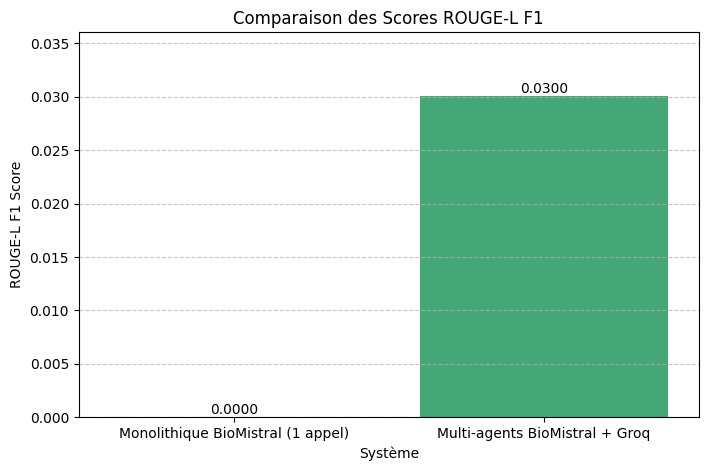

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting ROUGE-L F1
rouge_data = pd.DataFrame({
    'Système': [eval_mono['systeme'], eval_multi['systeme']],
    'ROUGE-L F1': [eval_mono['rouge_l_f1'], eval_multi['rouge_l_f1']]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Système', y='ROUGE-L F1', data=rouge_data, hue='Système', palette='viridis', legend=False)
plt.title('Comparaison des Scores ROUGE-L F1')
plt.ylabel('ROUGE-L F1 Score')
plt.ylim(0, max(rouge_data['ROUGE-L F1']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in rouge_data.iterrows():
    plt.text(index, row['ROUGE-L F1'], f'{row['ROUGE-L F1']:.4f}', color='black', ha="center", va='bottom')

plt.show()

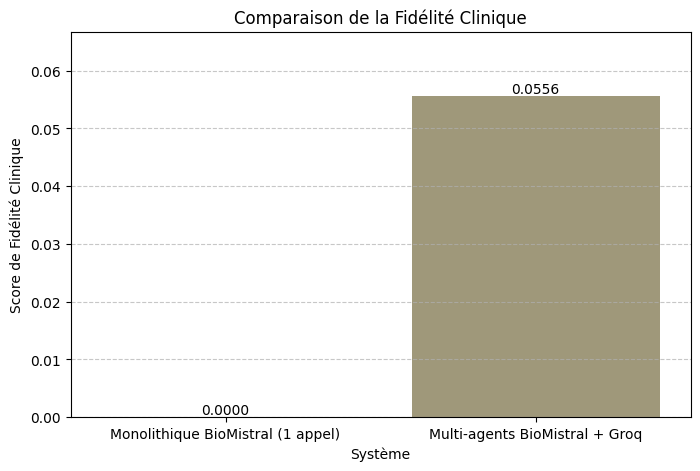

In [29]:
# Prepare data for plotting Clinical Fidelity
fidelite_data = pd.DataFrame({
    'Système': [eval_mono['systeme'], eval_multi['systeme']],
    'Fidélité clinique': [eval_mono['fidelite'], eval_multi['fidelite']]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Système', y='Fidélité clinique', data=fidelite_data, hue='Système', palette='cividis', legend=False)
plt.title('Comparaison de la Fidélité Clinique')
plt.ylabel('Score de Fidélité Clinique')
plt.ylim(0, max(fidelite_data['Fidélité clinique']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in fidelite_data.iterrows():
    plt.text(index, row['Fidélité clinique'], f'{row['Fidélité clinique']:.4f}', color='black', ha="center", va='bottom')

plt.show()

## Sauvegarde du modèle BioMistral-7B

In [30]:
import os

save_directory = "./BioMistral-7B-saved"

# Créer le répertoire si inexistant
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

print(f"Sauvegarde du modèle et du tokenizer dans {save_directory}...")

# Sauvegarder le tokenizer
tokenizer_bio.save_pretrained(save_directory)

# Sauvegarder le modèle
modele_bio.save_pretrained(save_directory)

print("Modèle et tokenizer BioMistral-7B sauvegardés avec succès !")

Sauvegarde du modèle et du tokenizer dans ./BioMistral-7B-saved...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle et tokenizer BioMistral-7B sauvegardés avec succès !


## Test du Système avec un Rapport Brut et le Modèle Sauvegardé

Cette section permet de tester le système complet en entrant un rapport de radiologie brut et en générant les résumés médecin et patient, en utilisant le modèle BioMistral-7B sauvegardé localement.

In [31]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import os

# Reconfiguration de la quantification 4-bit (doit correspondre à la sauvegarde)
config_4bit_loaded = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Chemin vers le répertoire du modèle sauvegardé
save_directory = "./BioMistral-7B-saved"

print(f"Chargement du modèle et du tokenizer depuis {save_directory}...")

# Charger le tokenizer
tokenizer_bio_loaded = AutoTokenizer.from_pretrained(save_directory)

# Charger le modèle
modele_bio_loaded = AutoModelForCausalLM.from_pretrained(
    save_directory,
    quantization_config=config_4bit_loaded,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)
modele_bio_loaded.eval()

# S'assurer que le pad token est défini
if tokenizer_bio_loaded.pad_token is None:
    tokenizer_bio_loaded.pad_token = tokenizer_bio_loaded.eos_token

print("Modèle BioMistral-7B chargé avec succès depuis le disque !")

# Les fonctions d'inférence doivent utiliser les modèles chargés
tokenizer_bio = tokenizer_bio_loaded
modele_bio = modele_bio_loaded

Chargement du modèle et du tokenizer depuis ./BioMistral-7B-saved...


/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Modèle BioMistral-7B chargé avec succès depuis le disque !


In [33]:
# Exemple de rapport de radiologie brut pour le test
rapport_brut_test = {
    "findings": "There is no evidence of acute cardiopulmonary disease. The heart size is normal. The lungs are clear bilaterally without focal consolidation, pleural effusion, or pneumothorax. No acute osseous abnormalities.",
    "impression": "Normal chest X-ray."
}

print("RAPPORT BRUT À TRAITER :\n")
print(rapport_brut_test["findings"])
print("\n" + "=" * 50 + "\n")

# Exécuter le pipeline complet avec le rapport brut
resultat_test_utilisateur = pipeline_complet(rapport_brut_test)

print("\n" + "=" * 50)
print("RÉSULTATS FINAUX POUR LE RAPPORT BRUT")
print("=" * 50)
print("\n RÉSUMÉ MÉDECIN GÉNÉRÉ :")
print(resultat_test_utilisateur["resume_medecin"])
print("\n RÉSUMÉ PATIENT GÉNÉRÉ :")
print(resultat_test_utilisateur["resume_patient"])
print(f"\n Vérifié    : {resultat_test_utilisateur['verification']['is_valid']}")
print(f"Confiance  : {resultat_test_utilisateur['verification']['confidence_score']}")

erreurs = resultat_test_utilisateur.get("erreurs", [])
if erreurs:
    print("\n Erreurs :")
    for e in erreurs:
        print(f"   - {e}")
else:
    print("\n Aucune erreur !")

RAPPORT BRUT À TRAITER :

There is no evidence of acute cardiopulmonary disease. The heart size is normal. The lungs are clear bilaterally without focal consolidation, pleural effusion, or pneumothorax. No acute osseous abnormalities.


Agent 1 : Extraction (BioMistral-7B)...
Agent 2 : Structuration (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 2: Findings Summary: The patient has a pneumothorax and a pleural effusion on the left side.
Validation error: 'unknown' is not one of ['normal', 'mild', 'moderate', 'severe']
Agent 3 : Vérification (BioMistral-7B)...
DEBUG: Raw BioMistral output for Agent 3: Is Valid: Yes
Agent 4A : Résumé médecin (Groq)...
Agent 4B : Résumé patient (Groq)...

RÉSULTATS FINAUX POUR LE RAPPORT BRUT

 RÉSUMÉ MÉDECIN GÉNÉRÉ :
The patient's imaging study reveals a discrepancy with the initial findings, as a pneumothorax and pleural effusion are present on the left side, contrary to the initial report of clear lungs. The severity level of these findings 